# Climate teleconnections and coastal temperature predictability

## Question and approach

**Do climate teleconnections leave different predictive fingerprints on the West Coast and East Coast?**

Here, a predictive fingerprint means three things: prediction skill, coefficient pattern, and residual behavior. We use current-season Niño 3.4, PDO, and AO to predict next-season seasonal temperature anomalies for broad West Coast and East Coast regions.

The models stay deliberately simple: a baseline, Niño-only regression, Niño+PDO regression, and a full multiple linear regression with Niño 3.4, PDO, and AO. We look for regional fingerprints, but the signal is weak and prediction skill is limited. That limitation is part of the result, not a side note.

### Notebook setup

The analysis cells stay short because repeated helper code lives in `project_helpers.py`. That file handles parsing, seasonal averaging, area weighting, model evaluation, and residual metrics.

In [1]:
import warnings

warnings.filterwarnings("ignore", message="Pandas requires version.*")
warnings.filterwarnings("ignore", message="Sorting by default.*")

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from project_helpers import (
    area_weighted_regional_mean,
    evaluate_models,
    lag_one_autocorrelation,
    load_monthly_csv_index,
    load_year_month_index,
    make_seasonal_mean,
)

plt.rcParams.update({"figure.dpi": 120})

## Temperature targets

Before we fit models, we need two target series that are comparable. ERA5 gives monthly 2m temperature on a grid, so we average it over one West Coast box and one East Coast box using latitude weights.

These boxes are broad regional proxies. They are easy to reproduce, but they are not land-only masks and should not be read as exact coastal boundaries. After averaging, we remove each region's usual seasonal cycle so the target is a seasonal temperature anomaly.

In [2]:
era5_data = xr.open_dataset("data/ERA5_2mtemp_1x1.nc")
temperature_variable = list(era5_data.data_vars)[0]
temperature_c = era5_data[temperature_variable] - 273.15

era5_summary = pd.DataFrame(
    {
        "item": ["variable", "first month", "last month"],
        "value": [
            temperature_variable,
            str(temperature_c.time.min().values)[:10],
            str(temperature_c.time.max().values)[:10],
        ],
    }
)
era5_summary

,item,value
0,variable,__xarray_dataarray_variable__
1,first month,1959-01-01
2,last month,2024-12-01


In [3]:
regions = {
    "West Coast": {"lat_min": 32, "lat_max": 49, "lon_min": 235, "lon_max": 244},
    "East Coast": {"lat_min": 25, "lat_max": 47, "lon_min": 279, "lon_max": 295},
}

region_table = pd.DataFrame(regions).T
region_table.index.name = "region"
region_table["lon_min_deg"] = region_table["lon_min"] - 360
region_table["lon_max_deg"] = region_table["lon_max"] - 360
region_table[["lat_min", "lat_max", "lon_min_deg", "lon_max_deg"]]

,lat_min,lat_max,lon_min_deg,lon_max_deg
region,,,,
West Coast,32,49,-125,-116
East Coast,25,47,-81,-65


The schematic below shows the two rectangular target regions before we turn the gridded data into time series.

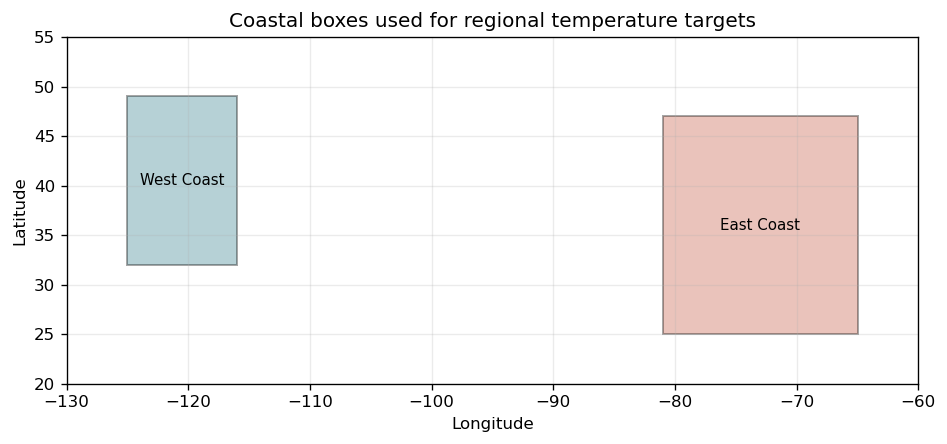

In [4]:
fig, ax = plt.subplots(figsize=(8, 3.8))
region_colors = {"West Coast": "#2F7C8C", "East Coast": "#C4553D"}

for region_name, row in region_table.iterrows():
    rect = Rectangle(
        (row["lon_min_deg"], row["lat_min"]),
        row["lon_max_deg"] - row["lon_min_deg"],
        row["lat_max"] - row["lat_min"],
        facecolor=region_colors[region_name],
        edgecolor="black",
        alpha=0.35,
        linewidth=1.2,
    )
    ax.add_patch(rect)
    ax.text(
        (row["lon_min_deg"] + row["lon_max_deg"]) / 2,
        (row["lat_min"] + row["lat_max"]) / 2,
        region_name,
        ha="center",
        va="center",
        fontsize=9,
    )

ax.set_xlim(-130, -60)
ax.set_ylim(20, 55)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Coastal boxes used for regional temperature targets")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [5]:
regional_temperature_monthly = pd.DataFrame(index=pd.to_datetime(temperature_c.time.values))

for region_name, region_box in regions.items():
    column_name = region_name.lower().replace(" ", "_") + "_temperature_c"
    regional_temperature_monthly[column_name] = area_weighted_regional_mean(
        temperature_c,
        region_box,
    ).to_series().values

In [6]:
seasonal_temperature = make_seasonal_mean(regional_temperature_monthly)

for coast in ["west_coast", "east_coast"]:
    temperature_column = coast + "_temperature_c"
    anomaly_column = coast + "_temperature_anomaly_c"
    seasonal_temperature[anomaly_column] = (
        seasonal_temperature[temperature_column]
        - seasonal_temperature.groupby("season")[temperature_column].transform("mean")
    )

target_summary = pd.DataFrame(
    {
        "target": ["West Coast anomaly", "East Coast anomaly"],
        "first season": seasonal_temperature["season_label"].iloc[0],
        "last season": seasonal_temperature["season_label"].iloc[-1],
        "missing values": [
            seasonal_temperature["west_coast_temperature_anomaly_c"].isna().sum(),
            seasonal_temperature["east_coast_temperature_anomaly_c"].isna().sum(),
        ],
    }
)
target_summary

,target,first season,last season,missing values
0,West Coast anomaly,1959 MAM,2024 SON,0
1,East Coast anomaly,1959 MAM,2024 SON,0


The anomaly time series is the first check on the target behavior. If the two coasts moved together every season, a regional comparison would not add much. If they differ, the same predictors may leave different marks on each coast.

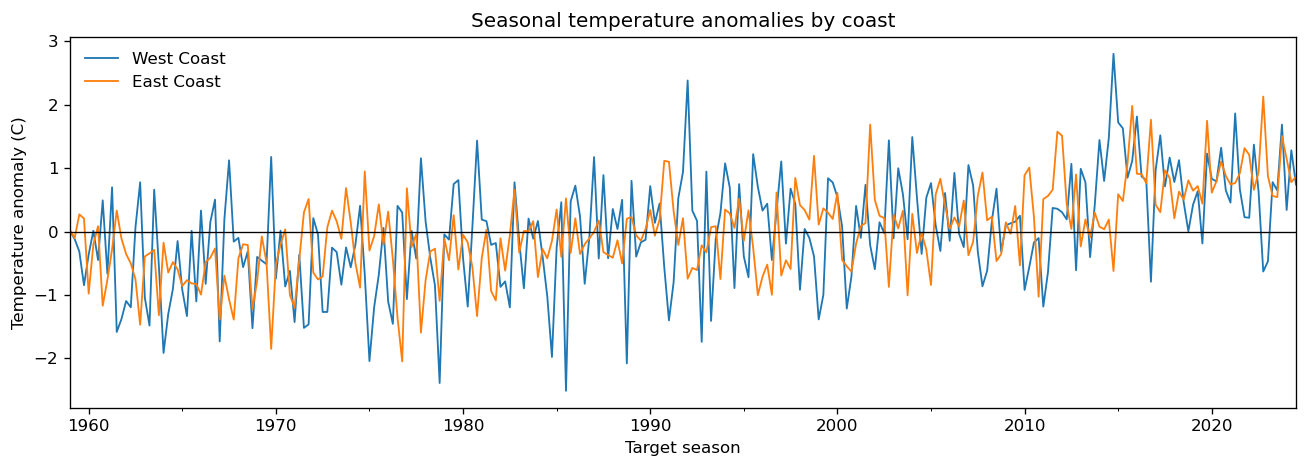

In [7]:
anomaly_plot_data = seasonal_temperature.set_index("date")[[
    "west_coast_temperature_anomaly_c",
    "east_coast_temperature_anomaly_c",
]]

ax = anomaly_plot_data.plot(figsize=(11, 4), linewidth=1.1)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Seasonal temperature anomalies by coast")
ax.set_xlabel("Target season")
ax.set_ylabel("Temperature anomaly (C)")
ax.legend(["West Coast", "East Coast"], frameon=False)
plt.tight_layout()
plt.show()

The two regions share some broad warm and cool periods, but they do not move in lockstep. The later part of the record also contains many positive anomalies. That matters later because a model trained mostly on earlier seasons has to predict a warmer held-out period using only three climate indices.

## Climate predictors

The predictor side is smaller than the temperature target side. Niño 3.4 and PDO summarize Pacific variability, while AO gives a broad measure of Northern Hemisphere circulation.

We average each monthly index into the same DJF, MAM, JJA, and SON seasons used for temperature. This keeps the timing consistent before we build the one-season-ahead table.

In [8]:
nino34_monthly = load_year_month_index("data/nina34.anom.data", "nino34")
pdo_monthly = load_year_month_index("data/ersst.v5.pdo.dat", "pdo")
ao_monthly = load_monthly_csv_index("data/ao.long.csv", "ao")

climate_indices_monthly = pd.concat(
    [nino34_monthly, pdo_monthly, ao_monthly],
    axis=1,
    sort=True,
).dropna(how="all")

seasonal_climate_indices = make_seasonal_mean(climate_indices_monthly)

In [9]:
predictor_summary = seasonal_climate_indices[["nino34", "pdo", "ao"]].agg(
    ["count", "mean", "std", "min", "max"]
).T
predictor_summary.round(2)

,count,mean,std,min,max
nino34,302.0,-0.17,0.85,-2.06,2.50
pdo,302.0,-0.48,1.09,-3.50,2.10
ao,302.0,-0.08,0.70,-3.42,2.69


The three predictors cover the full period needed for the regression table after seasonal averaging. The summary also gives a quick scale check: the indices are already centered near zero, so we can compare coefficient signs without first rescaling the variables.

## One-season-ahead dataset

Here we make the table that carries the prediction question. Each row pairs climate indices from one season with temperature anomaly in the following season.

The lag is simple, but it changes the interpretation. A same-season table would describe co-movement after the fact. This table asks whether current-season indices leave any signal for the next season.

In [10]:
predictor_table = seasonal_climate_indices[[
    "date", "season", "season_year", "season_id", "season_label", "nino34", "pdo", "ao",
]].copy()

predictor_table = predictor_table.rename(
    columns={
        "season_year": "predictor_season_year",
        "season_id": "predictor_season_id",
        "season_label": "predictor_season_label",
    }
)

In [11]:
target_table = seasonal_temperature[[
    "date",
    "season",
    "season_year",
    "season_id",
    "season_label",
    "west_coast_temperature_anomaly_c",
    "east_coast_temperature_anomaly_c",
]].copy()

target_table["predictor_season_id"] = target_table["season_id"] - 1

In [12]:
target_table = target_table.rename(
    columns={
        "date": "target_date",
        "season": "target_season",
        "season_year": "target_season_year",
        "season_id": "target_season_id",
        "season_label": "target_season_label",
        "west_coast_temperature_anomaly_c": "west_temperature_anomaly_next_season",
        "east_coast_temperature_anomaly_c": "east_temperature_anomaly_next_season",
    }
)

In [13]:
modeling_data = predictor_table.merge(target_table, on="predictor_season_id", how="inner")
modeling_data = modeling_data.dropna(
    subset=[
        "nino34",
        "pdo",
        "ao",
        "west_temperature_anomaly_next_season",
        "east_temperature_anomaly_next_season",
    ]
).sort_values("target_season_id").reset_index(drop=True)

modeling_columns = [
    "date", "season", "nino34", "pdo", "ao",
    "west_temperature_anomaly_next_season",
    "east_temperature_anomaly_next_season",
]

In [14]:
modeling_summary = pd.DataFrame(
    {
        "item": ["first predictor season", "last predictor season", "rows", "columns"],
        "value": [
            modeling_data["predictor_season_label"].iloc[0],
            modeling_data["predictor_season_label"].iloc[-1],
            len(modeling_data),
            len(modeling_columns),
        ],
    }
)

modeling_summary

,item,value
0,first predictor season,1959 DJF
1,last predictor season,2024 JJA
2,rows,263
3,columns,7


In [15]:
modeling_data[modeling_columns].head()

,date,season,nino34,pdo,ao,west_temperature_anomaly_next_season,east_temperature_anomaly_next_season
0,1958-12-01,DJF,0.326667,0.843333,-0.385333,0.008044,0.025009
1,1959-03-01,MAM,0.006667,-0.143333,0.403333,-0.117059,-0.104381
2,1959-06-01,JJA,-0.660000,-0.166667,-0.224333,-0.315661,0.270713
3,1959-09-01,SON,-0.646667,0.603333,-0.647000,-0.847931,0.204824
4,1959-12-01,DJF,-0.386667,0.623333,-1.579333,-0.362092,-0.980215


Before regression, we check how the predictors and targets relate to one another. This correlation check warns us when coefficients may move around because predictors share information.

In [16]:
correlation_columns = [
    "nino34",
    "pdo",
    "ao",
    "west_temperature_anomaly_next_season",
    "east_temperature_anomaly_next_season",
]
correlation_matrix = modeling_data[correlation_columns].corr()

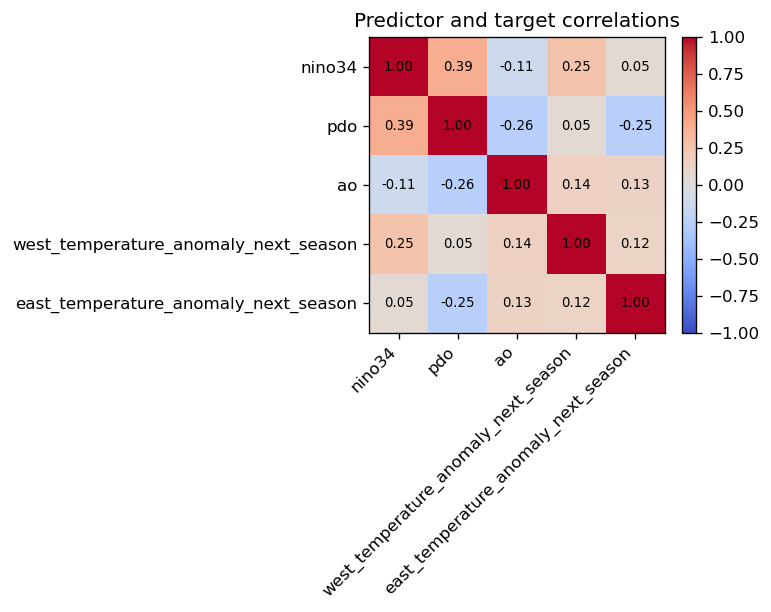

In [17]:
fig, ax = plt.subplots(figsize=(6.6, 5.2))
image = ax.imshow(correlation_matrix, vmin=-1, vmax=1, cmap="coolwarm")

ax.set_xticks(range(len(correlation_columns)))
ax.set_yticks(range(len(correlation_columns)))
ax.set_xticklabels(correlation_columns, rotation=45, ha="right")
ax.set_yticklabels(correlation_columns)

for row in range(len(correlation_columns)):
    for col in range(len(correlation_columns)):
        ax.text(
            col,
            row,
            f"{correlation_matrix.iloc[row, col]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
        )

ax.set_title("Predictor and target correlations")
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Niño 3.4 and PDO have a moderate positive correlation, so their coefficients should be read together rather than as isolated climate mechanisms. The West Coast target has a clearer positive relationship with Niño 3.4 than the East Coast target does. The East Coast relationship is weaker and leans more toward PDO in this setup.

## Regression comparison

Now we compare the same four models for each coast. The baseline uses the training-period mean and no climate information. The other three models add Niño 3.4, then PDO, then AO.

We use a time-ordered 80/20 split. Earlier seasons train the models, and later seasons test them. A random split would mix eras and make the one-season-ahead question look easier than it is.

In [18]:
model_specs = [
    ("Baseline", []),
    ("Niño-only", ["nino34"]),
    ("Niño + PDO", ["nino34", "pdo"]),
    ("Full", ["nino34", "pdo", "ao"]),
]

In [19]:
west_model_results, west_full_predictions = evaluate_models(
    modeling_data,
    "west_temperature_anomaly_next_season",
    "West Coast",
    model_specs,
)

east_model_results, east_full_predictions = evaluate_models(
    modeling_data,
    "east_temperature_anomaly_next_season",
    "East Coast",
    model_specs,
)

In [20]:
model_results = pd.concat([west_model_results, east_model_results], ignore_index=True)
full_model_predictions = pd.concat(
    [west_full_predictions, east_full_predictions],
    ignore_index=True,
)

performance_table = model_results[["region", "model", "RMSE", "MAE", "R2", "test_correlation"]]
performance_table = performance_table.rename(columns={"R2": "R²"})
performance_table.round(3)

,region,model,RMSE,MAE,R²,test_correlation
0,West Coast,Baseline,1.174,1.025,-1.914,NaN
1,West Coast,Niño-only,1.117,0.971,-1.639,0.316
2,West Coast,Niño + PDO,1.134,0.992,-1.719,0.363
3,West Coast,Full,1.115,0.962,-1.629,0.363
4,East Coast,Baseline,1.089,0.964,-3.080,NaN
5,East Coast,Niño-only,1.093,0.968,-3.115,-0.077
6,East Coast,Niño + PDO,1.028,0.902,-2.636,0.253
7,East Coast,Full,1.026,0.900,-2.625,0.265


In [21]:
coefficient_table = model_results[["region", "model", "nino34", "pdo", "ao"]]
coefficient_table.round(3)

,region,model,nino34,pdo,ao
0,West Coast,Baseline,NaN,NaN,NaN
1,West Coast,Niño-only,0.203,NaN,NaN
2,West Coast,Niño + PDO,0.184,0.037,NaN
3,West Coast,Full,0.188,0.076,0.174
4,East Coast,Baseline,NaN,NaN,NaN
5,East Coast,Niño-only,-0.020,NaN,NaN
6,East Coast,Niño + PDO,0.026,-0.090,NaN
7,East Coast,Full,0.026,-0.088,0.011


The performance table separates forecast skill from coefficient interpretation. RMSE and MAE measure error size, R² compares the test predictions with the test-period mean, and test correlation checks whether the predictions move in the right direction.

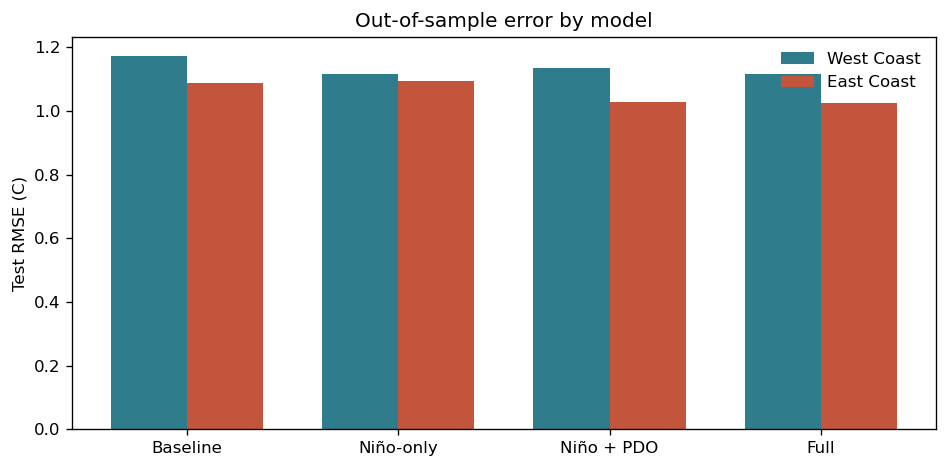

In [22]:
plot_order = ["Baseline", "Niño-only", "Niño + PDO", "Full"]
rmse_plot_data = performance_table.pivot(index="model", columns="region", values="RMSE").loc[plot_order]

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(rmse_plot_data.index))
width = 0.36

ax.bar(x - width / 2, rmse_plot_data["West Coast"], width, label="West Coast", color="#2F7C8C")
ax.bar(x + width / 2, rmse_plot_data["East Coast"], width, label="East Coast", color="#C4553D")

ax.set_xticks(x)
ax.set_xticklabels(rmse_plot_data.index)
ax.set_ylabel("Test RMSE (C)")
ax.set_title("Out-of-sample error by model")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

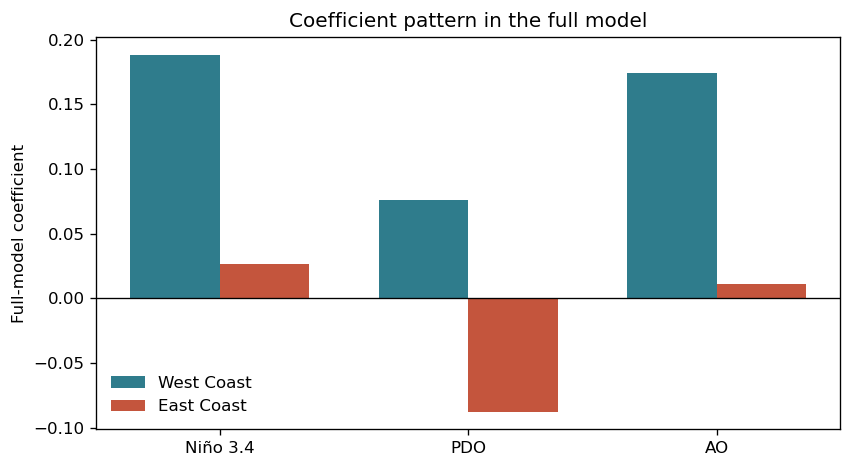

In [23]:
full_coefficients = coefficient_table[coefficient_table["model"] == "Full"]
full_coefficients = full_coefficients.set_index("region")[["nino34", "pdo", "ao"]]

fig, ax = plt.subplots(figsize=(7.2, 4))
x = np.arange(len(full_coefficients.columns))
width = 0.36

ax.bar(x - width / 2, full_coefficients.loc["West Coast"], width, label="West Coast", color="#2F7C8C")
ax.bar(x + width / 2, full_coefficients.loc["East Coast"], width, label="East Coast", color="#C4553D")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["Niño 3.4", "PDO", "AO"])
ax.set_ylabel("Full-model coefficient")
ax.set_title("Coefficient pattern in the full model")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The full model brings only a modest RMSE improvement over the baseline for both coasts. The test R² values remain negative because the held-out period has its own mean and variability; a negative value means the regression does worse than using the average of the test target values, which would not be known in a real forecast.

The West Coast fingerprint is somewhat clearer: the test correlation is higher, and the full-model coefficients keep a more visible Niño 3.4 signal. The East Coast improves when PDO is added, but the overall skill is still weak. More predictors do not turn these climate indices into a strong one-season forecast.

## What the model misses

Residual behavior is one part of the predictive fingerprint. We define residual as observed anomaly minus predicted anomaly. If the residuals are mostly positive in the test period, the model is underpredicting warmer anomalies.

This matters because the train/test split puts many later, warmer seasons in the test period. A regression trained on earlier data and driven only by climate indices may miss part of that background shift.

In [24]:
residual_summary = (
    full_model_predictions
    .groupby("region")
    .agg(
        mean_residual=("residual", "mean"),
        residual_std=("residual", "std"),
        minimum_residual=("residual", "min"),
        maximum_residual=("residual", "max"),
        lag1_residual_correlation=("residual", lag_one_autocorrelation),
    )
    .reset_index()
)

residual_summary.round(3)

,region,mean_residual,residual_std,minimum_residual,maximum_residual,lag1_residual_correlation
0,East Coast,0.884,0.527,-0.319,2.178,0.283
1,West Coast,0.912,0.647,-0.534,2.832,0.059


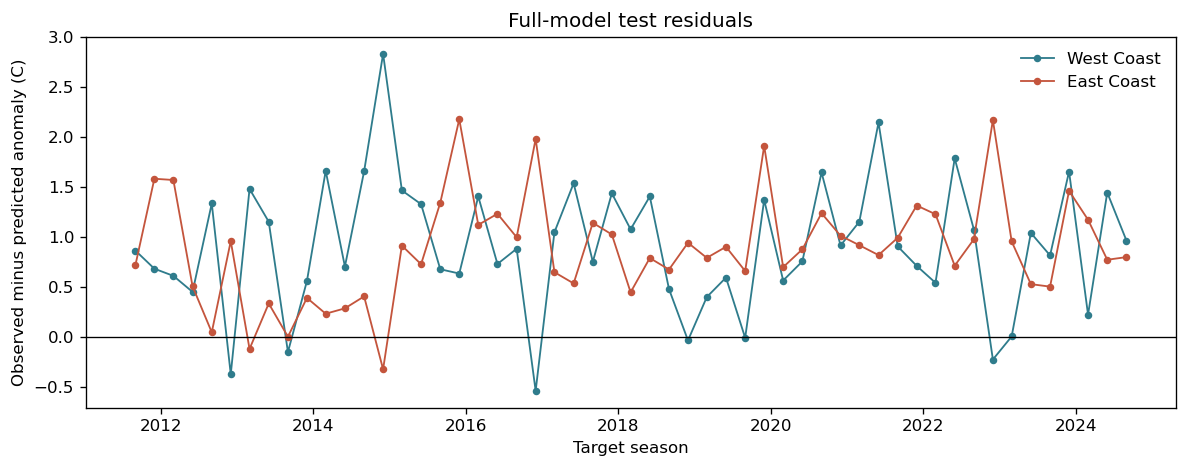

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))

for region_name, color in region_colors.items():
    region_predictions = full_model_predictions[full_model_predictions["region"] == region_name]
    ax.plot(
        region_predictions["target_date"],
        region_predictions["residual"],
        marker="o",
        linewidth=1.1,
        markersize=3.5,
        label=region_name,
        color=color,
    )

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Full-model test residuals")
ax.set_xlabel("Target season")
ax.set_ylabel("Observed minus predicted anomaly (C)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The mean residual is positive for both coasts. Since residual is observed minus predicted, that means the full model tends to underpredict warmer anomalies in the test period.

This is consistent with background warming or other nonstationary behavior that is not captured by Niño 3.4, PDO, and AO alone. It is not a causal claim about warming, and it does not mean the climate indices have no value. It says the simple teleconnection model misses part of the warmer later-period behavior.

## Main takeaways

- Prediction skill is limited. The full model improves RMSE only modestly, and test R² remains negative for both coasts.
- The West Coast signal is somewhat clearer than the East Coast signal. Niño 3.4 has a more visible role there, while the East Coast pattern is weaker and less stable.
- Climate indices alone miss part of the warmer later-period behavior. Positive full-model residuals show that the models tend to underpredict warm anomalies in the test period.